In [1]:
# Nettoyage complet
print("Nettoyage...")
%reset -f
%whos

Nettoyage...
Interactive namespace is empty.


In [2]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

In [3]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [4]:
requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
"""

requete_agences_negociateurs = """ 
-- On relie les négociateurs à leurs agences respectives
-- Ce sera utile pour localiser les négociateurs et leur attribuer les lots qu'ils gèreront

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    
    a.agence_id,
    a.age_nom AS agence_nom,
    a.age_ville AS agence_ville,
    a.age_code_postal AS agence_code_postal,
    a.age_adresse as agence_adresse,
    a.age_actif

FROM dbo.t_negociateur n
LEFT JOIN dbo.t_agence a
    ON n.agence_id = a.agence_id
"""

In [5]:
lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)
print(agences_negociateurs.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_14772\1735609369.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_14772\1735609369.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_14772\1735609369.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'agence_id',
       'agence_nom', 'agence_ville', 'agence_code_postal', 'agence_adresse',
       'age_actif'],
      dtype='object')


In [6]:
conn.commit()
cursor.close()
conn.close()

In [7]:
# # Cellule commentée pcq on l'a exécutée une fois et téléchargé l'excel qui en résulte

# # Extraire les colonnes liées aux agences
# colonnes_agence = ['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse', 'agence_code_postal']

# # Supprimer les doublons pour avoir une ligne par agence unique
# localisations_agences = agences_negociateurs[colonnes_agence].drop_duplicates().reset_index(drop=True)

# print(localisations_agences.columns)
# print(localisations_agences.shape)

# localisations_agences['adresse_complete'] = (
#     localisations_agences['agence_adresse'].astype(str) + ", " +
#     localisations_agences['agence_code_postal'].astype(str) + " " +
#     localisations_agences['agence_ville'].astype(str) + ", France"
# )

# print(localisations_agences.shape)

# # Pour obtenir les coordonnées géographiques des agences, nécessaires à l'affichage d'une carte
# # Compter 10 minutes d'exécution

# geolocator = Nominatim(user_agent="geocodage_agences")

# def geocode_adresse(adresse, retries=3):
#     for attempt in range(retries):
#         try:
#             location = geolocator.geocode(adresse, timeout = 15)
#             if location:
#                 return pd.Series([location.latitude, location.longitude])
#             else:
#                 return pd.Series([None, None])
#         except (GeocoderTimedOut, GeocoderUnavailable) as e:
#             print(f"Essai {attempt+1}/{retries} timeout pour {adresse}, retrying...")
#             time.sleep(2)  # pause avant retry
#         except Exception as e:
#             print(f"Erreur inattendue pour {adresse} : {e}")
#             break
#     return pd.Series([None, None])

# # Appliquer la fonction à chaque ligne
# latitudes = []
# longitudes = []

# i = 0
# for adresse in localisations_agences['adresse_complete'] :
#     i += 1
#     lat, lon = geocode_adresse(adresse)
#     latitudes.append(lat)
#     longitudes.append(lon)
#     print(f"Plus que {localisations_agences.shape[0] - i} coordonnées à caculer")
#     time.sleep(1.3) # Pour éviter d'être bloqué par le service. Si pb de timeout, augmenter le timesleep

# # Ajouter les colonnes au DataFrame
# localisations_agences['latitude'] = latitudes
# localisations_agences['longitude'] = longitudes

# localisations_agences.to_excel("localisations_agences.xlsx", index=False)

# print(localisations_agences.shape)

In [8]:
localisations_agences = pd.read_excel("localisations_agences.xlsx")

In [9]:
gdf_agences = gpd.GeoDataFrame(localisations_agences, geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude), crs="EPSG:4326")
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# Reprojeter en Web Mercator 
gdf_agences = gdf_agences.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_agences.shape)
print(gdf_offres.shape)

(284, 9)
(2422093, 11)


In [10]:
# # Ici on a tous les lots qui sont un jour passés dans LGP. C'est intéressant pour voir la masse totale 
# # du trafic sur les dernières années, mais si on souhaite faire une anbalyse actuelle, c'est fortement biaisé
# # par la croissance de LGP d'une part, mais aussi parce qu'on n'a pas de vue en t de l'état du marché à 
# # un moment "normal". On commente donc ici pour s'économiser du temps.

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=10, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# ax.set_xlim(-20037508, 20037508)
# ax.set_ylim(-8037508, 18037508)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()

# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

In [11]:
# # Ici on a tous les lots qui sont un jour passés dans LGP. C'est intéressant pour voir la masse totale 
# # du trafic sur les dernières années, mais si on souhaite faire une anbalyse actuelle, c'est fortement biaisé
# # par la croissance de LGP d'une part, mais aussi parce qu'on n'a pas de vue en t de l'état du marché à 
# # un moment "normal". On commente donc ici pour s'économiser du temps.

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=2, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# # Définir les limites France métropolitaine
# # Limites France métropolitaine en EPSG:3857
# ax.set_xlim(-560000, 1200000)
# ax.set_ylim(5000000, 6700000)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()
# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

**Attention, ces deux cartes précédentes montrent toutes les agences et toutes les offres qui ont un jour été actives. On affiche ci-dessous l'état actuel du marché** (sur l'échantillon LGP)

In [12]:
# Supprimer la colonne si elle existe déjà
if 'age_actif' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif', inplace=True)
if 'age_actif_x' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif_x', inplace=True)
if 'age_actif_y' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif_y', inplace=True)

# Supprimer la colonne si elle existe déjà
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

print(gdf_agences.columns)
print(gdf_offres.columns)

Index(['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse',
       'agence_code_postal', 'adresse_complete', 'latitude', 'longitude',
       'geometry'],
      dtype='object')
Index(['lot_id', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id', 'geometry'],
      dtype='object')


In [13]:
agences_actives = (agences_negociateurs.groupby('agence_id', as_index=False)['age_actif'].max())
gdf_agences = gdf_agences.merge(agences_actives, on='agence_id', how='left')

lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

In [14]:
# Filtrage : uniquement les points actifs
gdf_agences = gdf_agences[gdf_agences['age_actif'] == 1]
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

# Reprojeter en Web Mercator
gdf_agences = gdf_agences.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_agences.shape)
print(gdf_offres.shape)

(255, 10)
(2422090, 11)


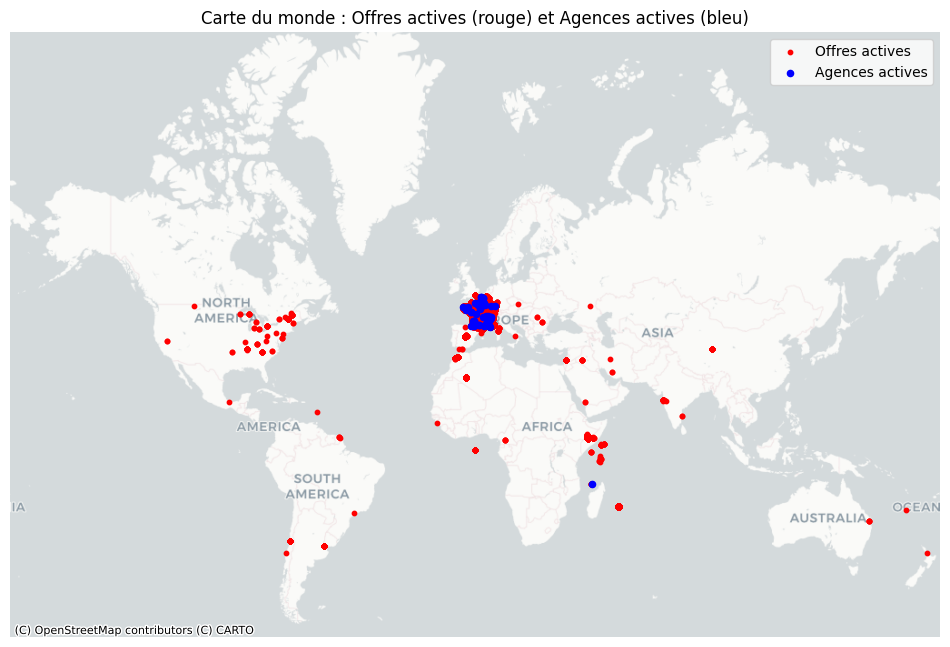

In [15]:
# Carte du monde
fig, ax = plt.subplots(figsize=(12, 12))

gdf_offres.plot(ax=ax, color='red', markersize=10, label='Offres actives')
gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences actives')

ax.set_xlim(-20037508, 20037508)
ax.set_ylim(-8037508, 18037508)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.legend()
ax.set_axis_off()
plt.title("Carte du monde : Offres actives (rouge) et Agences actives (bleu)")
plt.show()


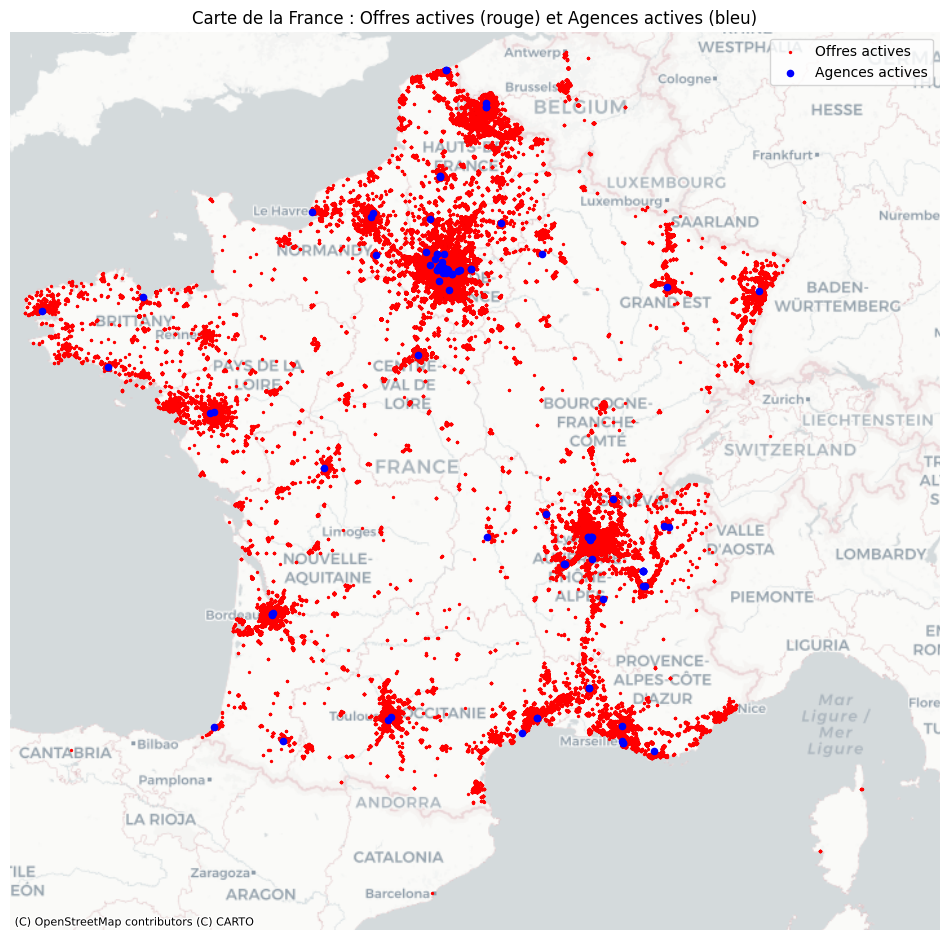

In [16]:
fig, ax = plt.subplots(figsize=(12, 12))

gdf_offres.plot(ax=ax, color='red', markersize=2, label='Offres actives')
gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences actives')

# Zoom sur la France
ax.set_xlim(-560000, 1200000)
ax.set_ylim(5000000, 6700000)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.legend()
ax.set_axis_off()
plt.title("Carte de la France : Offres actives (rouge) et Agences actives (bleu)")
plt.show()